# E5 - normalization ablation

Which normalization mechanism the conv blocks use, tested with dropout (0.5) and weight decay (1e-4) both held fixed - those were already covered in E3. `norm_batchnorm` is the existing baseline run, reused rather than retrained.

In [1]:
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from citrus_common import CitrusLeafDataset, get_transforms, load_normalization_stats
from citrus_model import CitrusNetRegNormAblation, init_weights
from citrus_train import set_seed, fit

os.makedirs("checkpoints", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
mean, std = load_normalization_stats("normalization_stats.json")

train_transform = get_transforms(augment=True, mean=mean, std=std, size=224)
val_transform = get_transforms(augment=False, mean=mean, std=std, size=224)

train_ds = CitrusLeafDataset("processed/224", "train", transform=train_transform)
val_ds = CitrusLeafDataset("processed/224", "val", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

len(train_ds), len(val_ds)

(1131, 242)

In [3]:
# order matches class_to_idx from the sorted folder names: aphids, gummosis, healthy, leaf_minnor
class_weights = torch.tensor([0.9921, 0.9240, 1.1880, 0.9363], dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Configs

`norm_weightnorm` is built the same way as `norm_none` (no norm layer in the model itself) and then gets `weight_norm` applied to every conv afterwards, on top of the already-initialized weights. dropout_p=0.5 and weight_decay=1e-4 are fixed for every config here.

In [4]:
config_params = {
    "norm_none":       {"normalization_type": "none"},
    "norm_layernorm":  {"normalization_type": "layernorm"},
    "norm_weightnorm": {"normalization_type": "none"},   # + weight_norm applied after init, see below
    "norm_batchnorm":  {"normalization_type": "batchnorm"},
}

new_configs = ["norm_none", "norm_layernorm", "norm_weightnorm"]

In [5]:
def history_to_df(history):
    return pd.DataFrame({
        "epoch": range(1, len(history["train_loss"]) + 1),
        "train_loss": history["train_loss"],
        "train_acc": history["train_acc"],
        "val_loss": history["val_loss"],
        "val_acc": history["val_acc"],
        "lr": history["lr"],
    })

In [6]:
def apply_weight_norm(model):
    """Wraps every Conv2d in block1-4 with weight_norm, in place, then reports
    on it. Done as a separate pass after init_weights so it reparameterizes
    already-initialized weights rather than affecting initialization.
    """
    wrapped_names = []
    for block_name in ["block1", "block2", "block3", "block4"]:
        block = getattr(model, block_name)
        for name, module in block.named_modules():
            if isinstance(module, nn.Conv2d):
                weight_norm(module)
                wrapped_names.append(f"{block_name}.{name}")

    # the current parametrize-based weight_norm stores the split under
    # module.parametrizations.weight rather than separate weight_g/weight_v
    # attributes (that naming belongs to the older, deprecated
    # torch.nn.utils.weight_norm) - check for that instead
    for block_name in ["block1", "block2", "block3", "block4"]:
        block = getattr(model, block_name)
        for name, module in block.named_modules():
            if isinstance(module, nn.Conv2d):
                is_parametrized = hasattr(module, "parametrizations") and "weight" in module.parametrizations
                print(f"{block_name}.{name}: parametrized = {is_parametrized}")

    return wrapped_names

In [7]:
results = {}
param_counts = {}

for name in new_configs:
    print(f"--- training {name} ---")
    set_seed(42)

    if name == "norm_weightnorm":
        model = CitrusNetRegNormAblation(num_classes=4, dropout_p=0.5, normalization_type="none")
        init_weights(model)
        wrapped = apply_weight_norm(model)
        print(f"applied weight_norm to {len(wrapped)} conv layers: {wrapped}")
    else:
        model = CitrusNetRegNormAblation(
            num_classes=4, dropout_p=0.5,
            normalization_type=config_params[name]["normalization_type"],
        )
        init_weights(model)

    model = model.to(device)

    n_params = sum(p.numel() for p in model.parameters())
    param_counts[name] = n_params
    print(f"{name}: {n_params} parameters")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = fit(
        model, train_loader, val_loader, criterion, optimizer, device,
        max_epochs=100, early_stop_patience=10, scheduler=scheduler,
        checkpoint_path=f"checkpoints/norm_{name}_best.pt",
    )

    df = history_to_df(history)
    df.to_csv(f"history_norm_{name}.csv", index=False)
    results[name] = df

extra_params = param_counts["norm_weightnorm"] - param_counts["norm_none"]
print(f"weight_norm adds {extra_params} extra parameters vs norm_none "
      f"(one magnitude scalar per output channel, per wrapped conv layer)")

--- training norm_none ---
norm_none: 415012 parameters
epoch   1  train_loss 1.7443  train_acc 0.2767  val_loss 1.2929  val_acc 0.4545  lr 1.00e-03
epoch   2  train_loss 1.1853  train_acc 0.4465  val_loss 0.8700  val_acc 0.5661  lr 1.00e-03
epoch   3  train_loss 0.9070  train_acc 0.5986  val_loss 0.5893  val_acc 0.7686  lr 1.00e-03
epoch   4  train_loss 0.6873  train_acc 0.7294  val_loss 0.3776  val_acc 0.8843  lr 1.00e-03
epoch   5  train_loss 0.5625  train_acc 0.7834  val_loss 0.4388  val_acc 0.8471  lr 1.00e-03
epoch   6  train_loss 0.5423  train_acc 0.7719  val_loss 0.5559  val_acc 0.8099  lr 1.00e-03
epoch   7  train_loss 0.4662  train_acc 0.8170  val_loss 0.3158  val_acc 0.8884  lr 1.00e-03
epoch   8  train_loss 0.3601  train_acc 0.8594  val_loss 0.2145  val_acc 0.9215  lr 1.00e-03
epoch   9  train_loss 0.4131  train_acc 0.8400  val_loss 0.2060  val_acc 0.9298  lr 1.00e-03
epoch  10  train_loss 0.3641  train_acc 0.8709  val_loss 0.1823  val_acc 0.9380  lr 1.00e-03
epoch  11  tra

In [8]:
# norm_batchnorm already trained in Section V - load it instead of retraining
baseline_df = pd.read_csv("history_baseline.csv")
results["norm_batchnorm"] = baseline_df
param_counts["norm_batchnorm"] = 416036

In [9]:
def summarize(name, df):
    best_idx = df["val_loss"].idxmin()
    best_epoch = int(df.loc[best_idx, "epoch"])
    best_val_loss = float(df.loc[best_idx, "val_loss"])
    best_val_acc = float(df.loc[best_idx, "val_acc"])

    reached_99 = df[df["val_acc"] >= 0.99]
    epochs_to_99 = int(reached_99["epoch"].iloc[0]) if len(reached_99) > 0 else "never"

    return {
        "config": name,
        "normalization_type": config_params[name]["normalization_type"] if name != "norm_weightnorm" else "weightnorm",
        "param_count": param_counts[name],
        "epochs_run": int(df["epoch"].max()),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "epochs_to_reach_99pct": epochs_to_99,
    }

order = ["norm_none", "norm_layernorm", "norm_weightnorm", "norm_batchnorm"]
summary_df = pd.DataFrame([summarize(name, results[name]) for name in order])
print(summary_df.to_string(index=False))
summary_df

         config normalization_type  param_count  epochs_run  best_epoch  best_val_loss  best_val_acc  epochs_to_reach_99pct
      norm_none               none       415012          67          57       0.000773           1.0                     15
 norm_layernorm          layernorm       416036          87          77       0.001919           1.0                     23
norm_weightnorm         weightnorm       415556          84          74       0.000958           1.0                     28
 norm_batchnorm          batchnorm       416036          40          30       0.001026           1.0                      4


,config,normalization_type,param_count,epochs_run,best_epoch,best_val_loss,best_val_acc,epochs_to_reach_99pct
0,norm_none,none,415012,67,57,0.000773,1.0,15
1,norm_layernorm,layernorm,416036,87,77,0.001919,1.0,23
2,norm_weightnorm,weightnorm,415556,84,74,0.000958,1.0,28
3,norm_batchnorm,batchnorm,416036,40,30,0.001026,1.0,4


## Plots

Both figures overlay all four configs. Val_loss is on a log scale, same reasoning as E3 - accuracy alone is near ceiling for all of them.

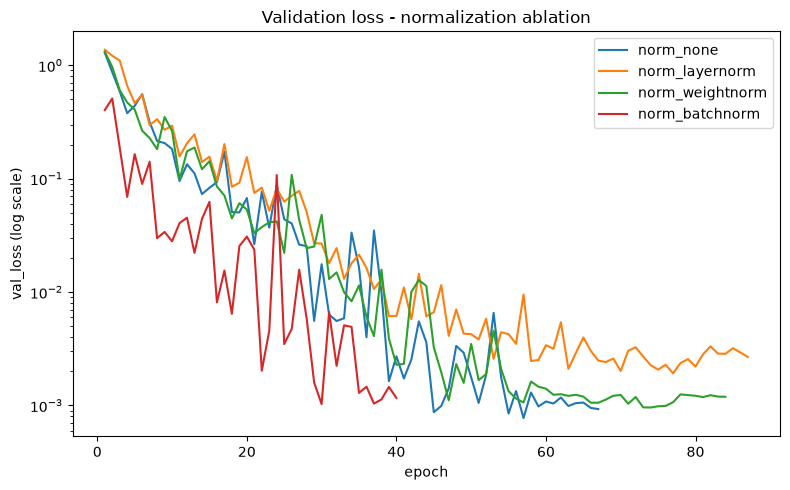

In [10]:
plt.figure(figsize=(8, 5))
for name in order:
    df = results[name]
    plt.plot(df["epoch"], df["val_loss"], label=name)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val_loss (log scale)")
plt.title("Validation loss - normalization ablation")
plt.legend()
plt.tight_layout()
plt.show()

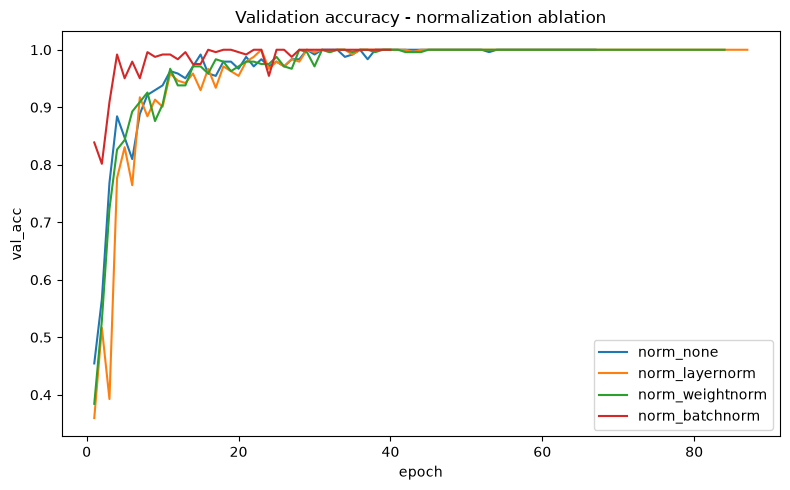

In [11]:
plt.figure(figsize=(8, 5))
for name in order:
    df = results[name]
    plt.plot(df["epoch"], df["val_acc"], label=name)
plt.xlabel("epoch")
plt.ylabel("val_acc")
plt.title("Validation accuracy - normalization ablation")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def check_instability(df, spike_ratio=3.0, spike_abs=0.05):
    """Flags epochs where val_loss jumps sharply from the previous epoch -
    a simple stand-in for the kind of spikes seen for RMSprop/Adagrad in the
    optimizer ablation, not a rigorous statistical test.
    """
    losses = df["val_loss"].values
    epochs = df["epoch"].values
    spikes = []
    for i in range(1, len(losses)):
        if losses[i] > losses[i - 1] * spike_ratio and losses[i] > spike_abs:
            spikes.append(int(epochs[i]))
    return spikes

numeric_99 = summary_df[summary_df["epochs_to_reach_99pct"].apply(lambda x: isinstance(x, (int, float)))]
fastest_row = numeric_99.sort_values("epochs_to_reach_99pct").iloc[0]
lowest_loss_row = summary_df.loc[summary_df["best_val_loss"].idxmin()]

print(f"fastest to reach 99% val_acc: {fastest_row['config']} (epoch {fastest_row['epochs_to_reach_99pct']})")
print(f"lowest best_val_loss: {lowest_loss_row['config']} ({lowest_loss_row['best_val_loss']:.5f})")

failed_99 = summary_df[summary_df["epochs_to_reach_99pct"] == "never"]["config"].tolist()
if failed_99:
    print(f"did not reach 99% val_acc: {failed_99}")
else:
    print("all configs reached 99% val_acc")

any_unstable = False
for name in order:
    spikes = check_instability(results[name])
    if spikes:
        any_unstable = True
        print(f"{name}: val_loss spike(s) at epoch(s) {spikes}")
if not any_unstable:
    print("no large val_loss spikes detected in any config")

fastest to reach 99% val_acc: norm_batchnorm (epoch 4)
lowest best_val_loss: norm_none (0.00077)
all configs reached 99% val_acc
norm_weightnorm: val_loss spike(s) at epoch(s) [26]
norm_batchnorm: val_loss spike(s) at epoch(s) [24]
